In [1]:
import os


import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import timm
import copy
import math
import time
from pathlib import Path
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm.auto import tqdm

import litert_torch
import torch
import torch.nn as nn
import torch.optim as optim
from ai_edge_litert.interpreter import Interpreter
from ai_edge_quantizer import quantizer, recipe
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
       torch.cuda.manual_seed(seed)
       torch.cuda.manual_seed_all(seed)
       torch.backends.cudnn.deterministic = False
       torch.backends.cudnn.benchmark = True

set_seed(SEED)

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


In [2]:
!pwd

/home/jovyan/work/UFSC/butterflies_austria/pytorch_mobilevit_xxs/MobileNetV2/butterflies_austria_MobileNetv2


# Setup

In [3]:
PATH = "/home/jovyan/work/UFSC/butterflies_austria/Dataset_train_test_split/butterflies-austria"

EPOCHS = 40
PATIENCE_ES = 8

BATCH_SIZE = 64


LR = 1e-3
MIN_LR = 1e-7
GRAD_CLIP = 1.0

IMG_SIZE = (224, 224)
MODEL_SAVE_PATH = "best__model.pt"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")

Device: cuda


# Dataset

In [4]:
NORMALIZE_MEAN = (0.485, 0.456, 0.406)
NORMALIZE_STD = (0.229, 0.224, 0.225)

In [5]:
train_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.Lambda(lambda image: image.convert("RGB")),
    transforms.RandomHorizontalFlip(p=0.1),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.Lambda(lambda image: image.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
])

In [6]:
train_dir = os.path.join(PATH, "train")
val_dir = os.path.join(PATH, "val")
test_dir = os.path.join(PATH, "test")

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

class_names = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

if val_dataset.class_to_idx != class_to_idx:
    raise ValueError("Training and validation classes are not aligned")

if test_dataset.class_to_idx != class_to_idx:
    raise ValueError("Training and test classes are not aligned")

pin_memory = DEVICE.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=pin_memory,
    persistent_workers=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=pin_memory,
    persistent_workers=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=pin_memory,
    persistent_workers=True,
)

print(f"Classes: {len(class_names)}")
print(
    f"Train: {len(train_dataset)} | "
    f"Val: {len(val_dataset)} | "
    f"Test: {len(test_dataset)}"
)

Classes: 20
Train: 5183 | Val: 648 | Test: 648


Training distribution:
  Aglais_Urticae                : 215
  Anthocharis_Cardamines        : 361
  Apatura_Iris                  : 279
  Argynnis_Paphia               : 316
  Colias_Myrmidone              : 227
  Gonepteryx_Rhamni             : 186
  Inachis_Io                    : 218
  Iphiclides_Podalirius         : 238
  Lycaena_Virgaureae            : 137
  Lycaenidae                    : 332
  Maniola_Jurtina               : 326
  Melanargia_Galathea           : 328
  Nymphalis_Antiopa             : 128
  Papilio_Machaon               : 194
  Parnassius_Apollo             : 247
  Pieris_Rapae                  : 294
  Polygonia_C-album             : 317
  Vanessa_Atalanta              : 379
  Vanessa_Cardui                : 266
  Zerynthia_Polyxena            : 195


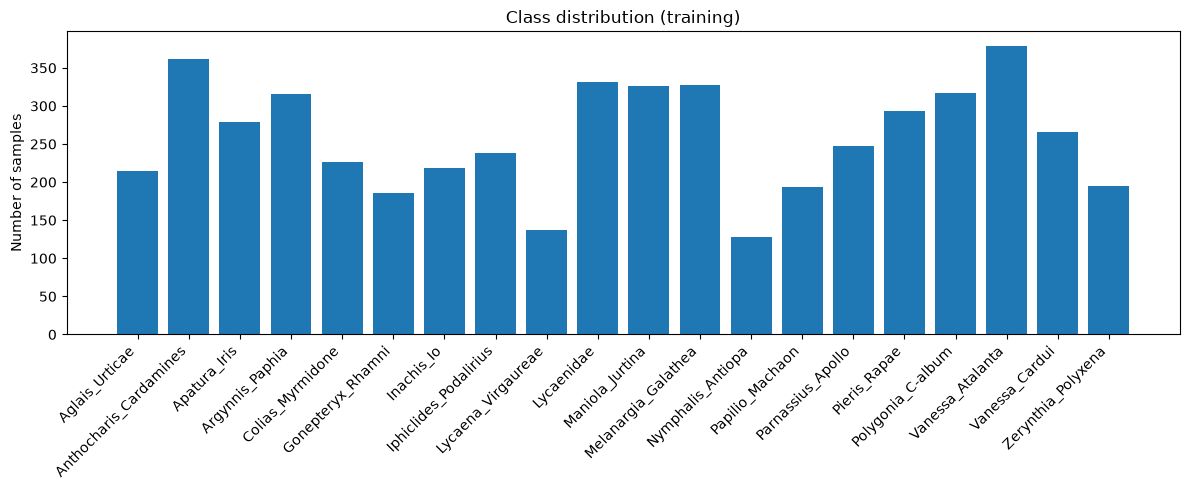

Class weights: [1.0633659362792969, 0.8206319212913513, 0.9334689974784851, 0.8771188855171204, 1.0348777770996094, 1.1432613134384155, 1.0560239553451538, 1.0106796026229858, 1.3321149349212646, 0.8557224869728088, 0.8635613322257996, 0.8609245419502258, 1.3781516551971436, 1.1194407939910889, 0.9920955896377563, 0.9093442559242249, 0.8757343292236328, 0.800907552242279, 0.9560072422027588, 1.116566777229309]


In [7]:
train_targets = np.asarray(train_dataset.targets)
train_counts = np.bincount(train_targets, minlength=len(class_names))

print("Training distribution:")
for name, count in zip(class_names, train_counts):
    print(f"  {name:30s}: {count}")

plt.figure(figsize=(12, 5))
plt.bar(class_names, train_counts)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of samples")
plt.title("Class distribution (training)")
plt.tight_layout()
plt.show()

class_weights = len(train_targets) / (
    len(class_names) * train_counts
)

class_weights = np.sqrt(class_weights)
class_weights = class_weights / class_weights.mean()

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE,
)
print(f"Class weights: {class_weights.tolist()}")

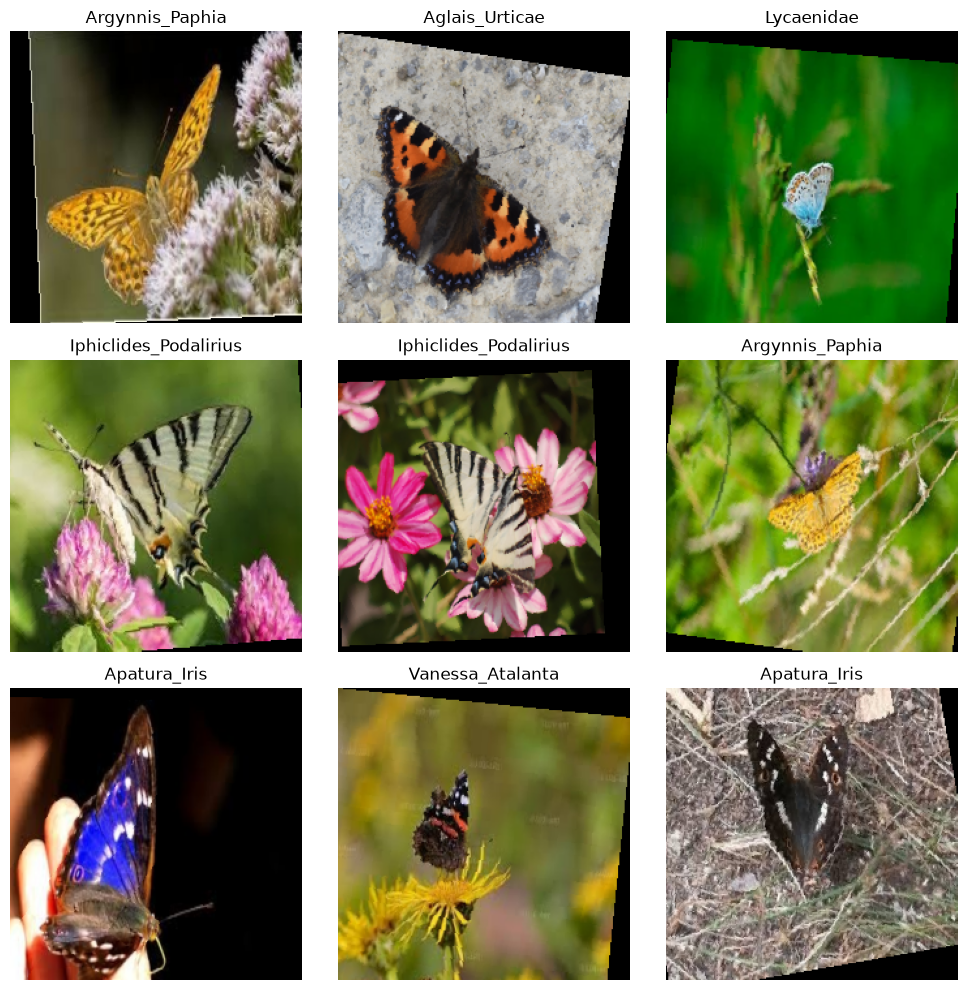

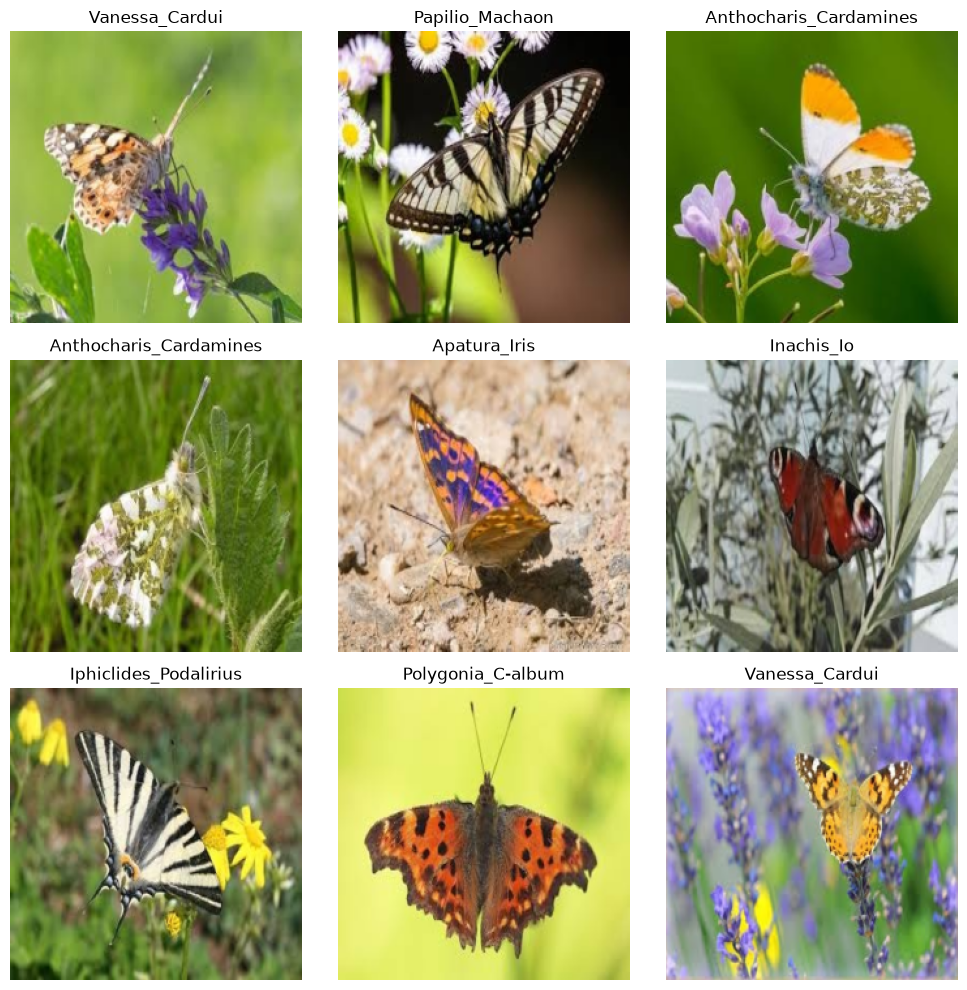

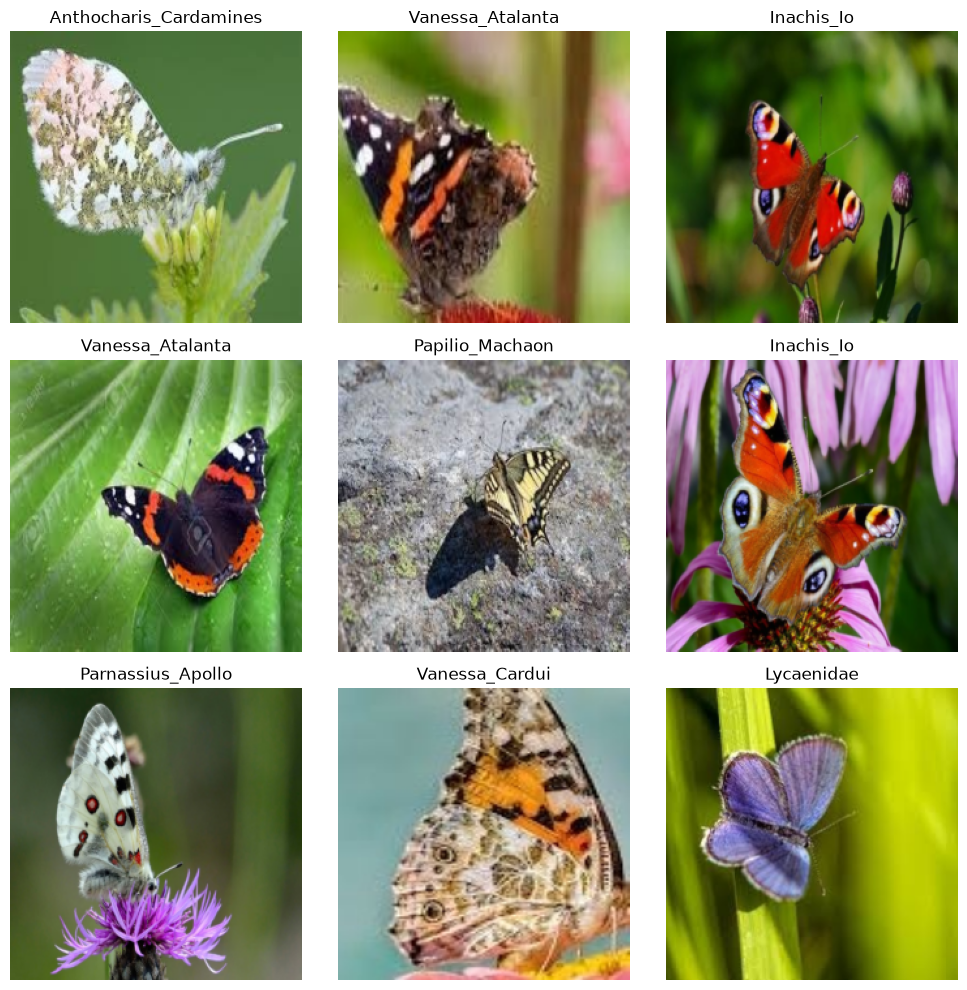

In [8]:
def plot_samples(dataset, class_names, num_samples=9):
    cols = 3
    rows = math.ceil(num_samples / cols)
    plt.figure(figsize=(10, 10))
    
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    indices = random.sample(range(len(dataset)), num_samples)
    for i, idx in enumerate(indices):
        img_tensor, label = dataset[idx]
        img_np = (img_tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        
        ax = plt.subplot(rows, cols, i + 1)
        plt.imshow(img_np)
        plt.title(class_names[label])
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

plot_samples(train_dataset, class_names)
plot_samples(test_dataset, class_names)
plot_samples(val_dataset, class_names)

# Model

In [9]:
model = timm.create_model(
    "mobilenetv2_100",
    pretrained=True,
    num_classes=len(class_names),
    drop_rate=0.3,
).to(DEVICE)

model.safetensors: reconstructing file:   0%|          |  0.00B / 14.2MB            

model.safetensors: downloading bytes:           |  0.00B            

In [10]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params:,}")

Total Parameters: 2,249,492


# Train

In [11]:
# Fine-tuning: classifier novo (aleatorio) precisa de LR maior que o backbone pre-treinado
backbone_params = [p for n, p in model.named_parameters() if 'classifier' not in n]
head_params     = [p for n, p in model.named_parameters() if 'classifier' in n]

optimizer = optim.AdamW(
    [
        {"params": backbone_params, "lr": LR / 10},
        {"params": head_params, "lr": LR},
    ],
    weight_decay=1e-4,
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.05,
)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[LR / 10, LR],
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    div_factor=100,
    final_div_factor=100,
)

# Treinamento
best_acc = 0.0
patience_counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [12]:
print("Starting training...")

for epoch in tqdm(range(EPOCHS), desc="Training Progress"):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct_train / total_train
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    model.eval()
    val_loss_running = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss_running += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = val_loss_running / len(val_dataset)
    val_acc = correct_val / total_val
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    tqdm.write(
        f"[{epoch+1:03d}/{EPOCHS}] "
        f"train_loss={epoch_loss:.4f} train_acc={epoch_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"lr={current_lr:.2e}"
    )

    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE_ES:
            tqdm.write(f"Early stopping triggered at epoch {epoch + 1}.")
            break

model.load_state_dict(best_model_wts)
print(f"Best validation accuracy: {best_acc:.4f}")

Starting training...


Training Progress:   0%|          | 0/40 [00:00<?, ?it/s]

[001/40] train_loss=4.7116 train_acc=0.0459 | val_loss=4.1047 val_acc=0.0509 | lr=2.69e-06
[002/40] train_loss=4.3970 train_acc=0.0585 | val_loss=3.6509 val_acc=0.0617 | lr=7.65e-06
[003/40] train_loss=3.7875 train_acc=0.1086 | val_loss=2.9720 val_acc=0.1651 | lr=1.55e-05
[004/40] train_loss=2.8506 train_acc=0.2537 | val_loss=2.0662 val_acc=0.4213 | lr=2.58e-05
[005/40] train_loss=1.9385 train_acc=0.4889 | val_loss=1.2969 val_acc=0.6806 | lr=3.78e-05
[006/40] train_loss=1.2923 train_acc=0.7021 | val_loss=0.9156 val_acc=0.8287 | lr=5.06e-05
[007/40] train_loss=0.9765 train_acc=0.8179 | val_loss=0.7627 val_acc=0.8981 | lr=6.34e-05
[008/40] train_loss=0.7916 train_acc=0.8767 | val_loss=0.6723 val_acc=0.9259 | lr=7.53e-05
[009/40] train_loss=0.6987 train_acc=0.9074 | val_loss=0.6328 val_acc=0.9414 | lr=8.56e-05
[010/40] train_loss=0.6071 train_acc=0.9396 | val_loss=0.5795 val_acc=0.9475 | lr=9.34e-05
[011/40] train_loss=0.5674 train_acc=0.9523 | val_loss=0.5589 val_acc=0.9568 | lr=9.84e-05

# Test

Final test accuracy: 0.9707


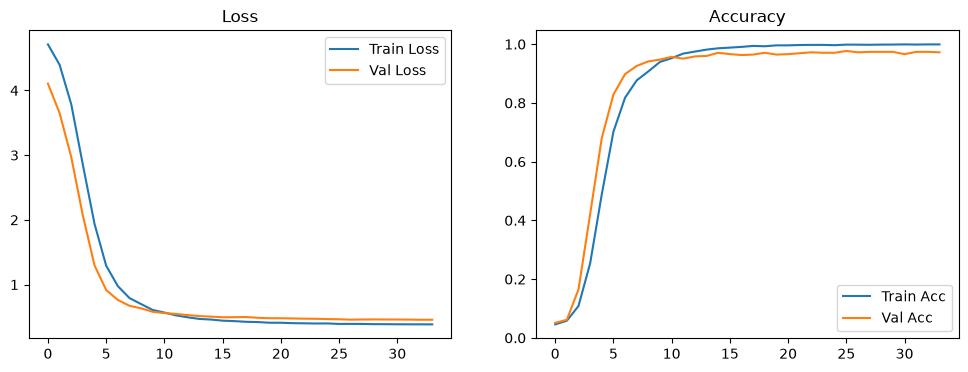

In [13]:
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

print(f"Final test accuracy: {test_correct / test_total:.4f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title("Accuracy")
plt.show()

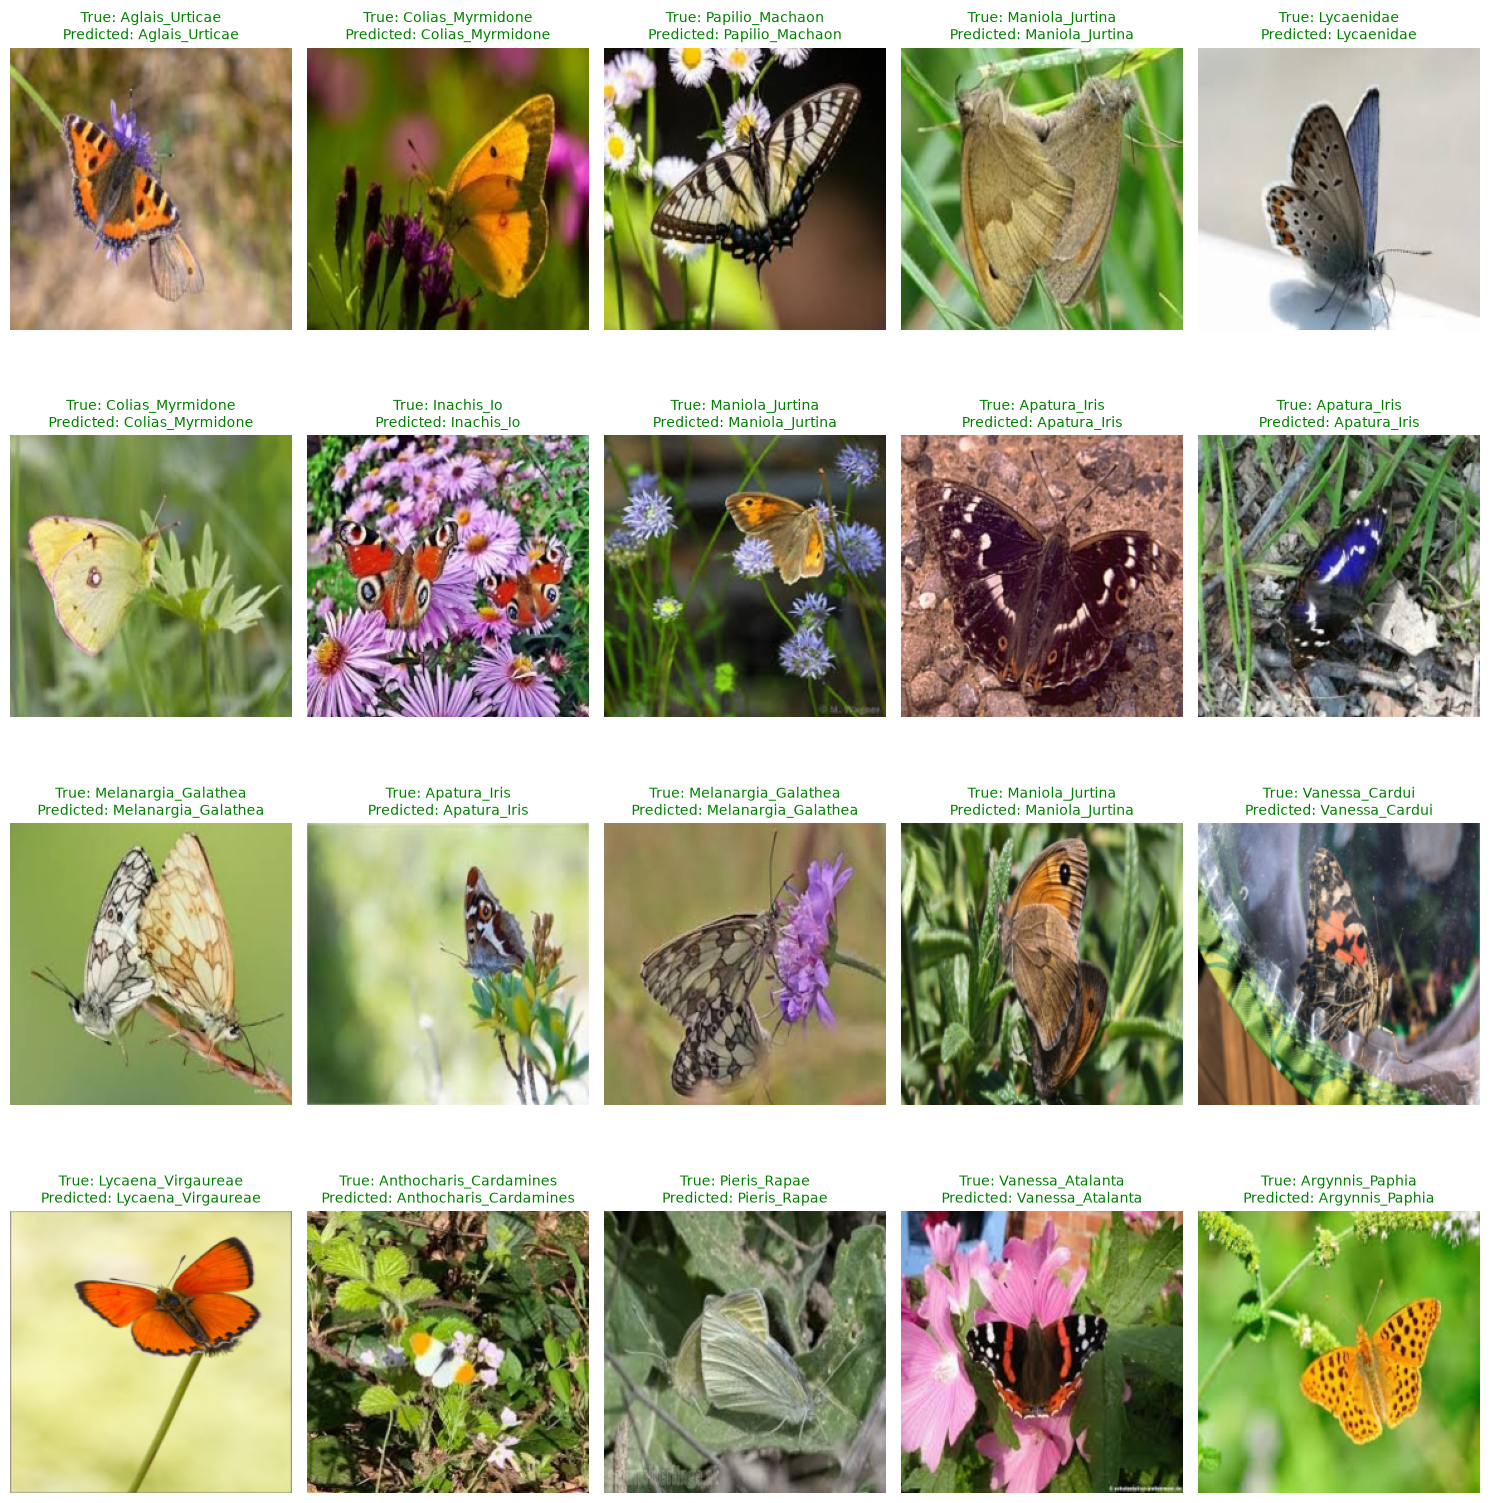

In [14]:
def predict_and_plot(model, dataset, classes, num_samples=10):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    model.eval()
    indices = random.sample(range(len(dataset)), num_samples)

    cols = 5
    rows = math.ceil(num_samples / cols)

    plt.figure(figsize=(15, 4 * rows))
    for i, idx in enumerate(indices):
        img_tensor, label = dataset[idx]
        img_input = img_tensor.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            output = model(img_input)
            pred = output.argmax(dim=1).item()

        img_np = (img_tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_np)

        color = 'green' if pred == label else 'red'
        plt.title(f"True: {classes[label]}\nPredicted: {classes[pred]}", color=color, fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

predict_and_plot(model, test_dataset, class_names, num_samples=20)

                        precision    recall  f1-score   support

        Aglais_Urticae     1.0000    0.9630    0.9811        27
Anthocharis_Cardamines     1.0000    0.9556    0.9773        45
          Apatura_Iris     0.9722    1.0000    0.9859        35
       Argynnis_Paphia     1.0000    1.0000    1.0000        40
      Colias_Myrmidone     1.0000    0.9286    0.9630        28
     Gonepteryx_Rhamni     0.8800    0.9565    0.9167        23
            Inachis_Io     0.9643    0.9643    0.9643        28
 Iphiclides_Podalirius     1.0000    1.0000    1.0000        29
    Lycaena_Virgaureae     0.9412    0.9412    0.9412        17
            Lycaenidae     0.9756    0.9756    0.9756        41
       Maniola_Jurtina     1.0000    0.9512    0.9750        41
   Melanargia_Galathea     0.9762    1.0000    0.9880        41
     Nymphalis_Antiopa     1.0000    0.9375    0.9677        16
       Papilio_Machaon     1.0000    1.0000    1.0000        24
     Parnassius_Apollo     1.0000    0.

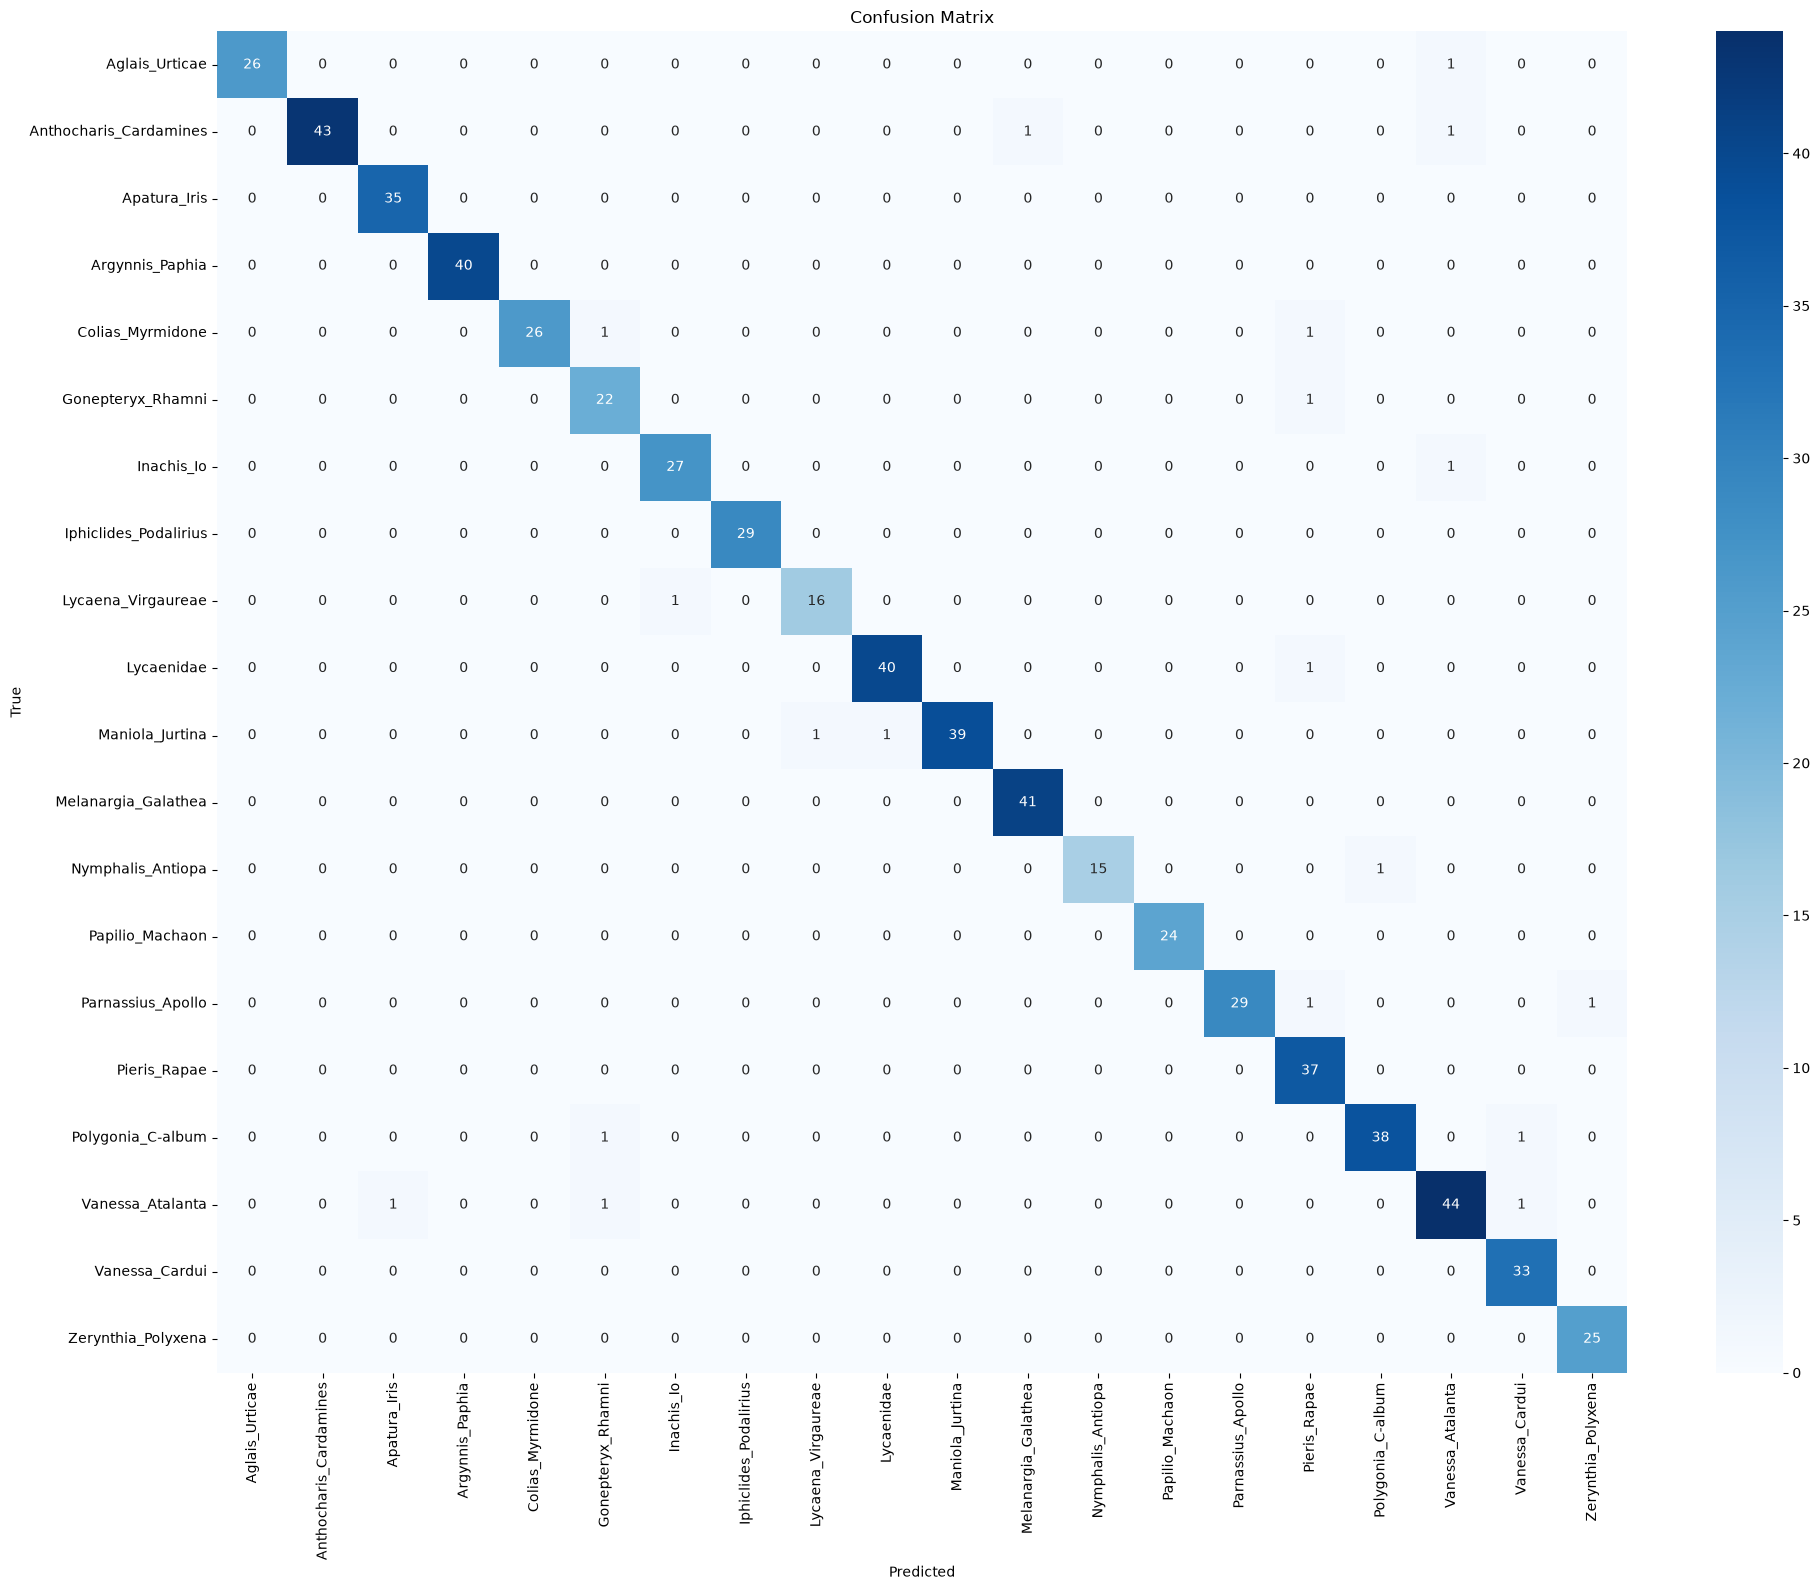

In [15]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

labels = range(len(class_names))

print(
    classification_report(
        all_labels,
        all_preds,
        labels=labels,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

cm = confusion_matrix(all_labels, all_preds, labels=labels)
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Export Edge AI

In [16]:
EXPORT_DIR = Path("tflite_models")
EXPORT_DIR.mkdir(exist_ok=True)

NUM_CALIB_SAMPLES = 100

FP32_PATH = EXPORT_DIR / "model_fp32.tflite"
INT8A16_PATH = EXPORT_DIR / "model_int8a16.tflite"
INT8_PATH = EXPORT_DIR / "model_int8.tflite"

In [17]:
calibration_dataset = datasets.ImageFolder(train_dir, transform=val_test_transforms)

In [18]:
export_model = copy.deepcopy(model).cpu().eval()

sample_image = test_dataset[0][0]
sample_inputs = (sample_image.unsqueeze(0).cpu(),)

print(sample_inputs[0].shape)

torch.Size([1, 3, 224, 224])


In [19]:
edge_model = litert_torch.convert(export_model, sample_inputs)
edge_model.export(str(FP32_PATH))

print(f"FP32: {FP32_PATH.stat().st_size / 1024 / 1024:.2f} MB")

(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

(00:01) [START] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions

/opt/conda/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


(00:02) [ DONE] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions (+00:01)

...

(00:09) [ DONE] LiteRT-Torch Convert (+00:09)

(00:00) [START] Write Model to tflite_models/model_fp32.tflite

I0000 00:00:1789402553.733713     600 flatbuffer_export.cc:4342] Estimated count of arithmetic ops: 605.934 M  ops, equivalently 302.967 M  MACs


(00:00) [ DONE] Write Model to tflite_models/model_fp32.tflite (+00:00)

FP32: 8.63 MB


In [20]:
def create_calibration_data(model_path, dataset, num_samples=200, seed=42):
    interpreter = Interpreter(model_path=str(model_path))
    signatures = interpreter.get_signature_list()

    if len(signatures) != 1:
        raise ValueError(f"Expected one signature, found: {list(signatures)}")

    signature_name, signature = next(iter(signatures.items()))
    input_names = signature["inputs"]

    if len(input_names) != 1:
        raise ValueError(f"Expected one input, found: {input_names}")

    input_name = input_names[0]

    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(len(dataset), generator=generator)[:min(num_samples, len(dataset))].tolist()

    samples = []

    for index in indices:
        image = dataset[index][0]
        samples.append({input_name: image.unsqueeze(0).cpu().numpy().astype(np.float32)})

    return {signature_name: samples}

calibration_data = create_calibration_data(FP32_PATH, calibration_dataset, NUM_CALIB_SAMPLES)

In [21]:
def quantize_static(fp32_path, output_path, calibration_data, quantization_recipe):
    qt = quantizer.Quantizer(str(fp32_path))
    qt.load_quantization_recipe(quantization_recipe())
    calibration_result = qt.calibrate(calibration_data)
    result = qt.quantize(calibration_result)
    result.export_model(str(output_path), overwrite=True)

    print(f"{output_path.name}: {output_path.stat().st_size / 1024 / 1024:.2f} MB")

In [22]:
quantize_static(FP32_PATH, INT8A16_PATH, calibration_data, recipe.static_wi8_ai16)

/opt/conda/lib/python3.11/site-packages/ai_edge_litert/interpreter.py:480: UserWarning: Warning: Enabling `experimental_preserve_all_tensors` with the BUILTIN or AUTO op resolver is intended for debugging purposes only. Be aware that this can significantly increase memory usage by storing all intermediate tensors. If you encounter memory problems or are not actively debugging, consider disabling this option.
  warnings.warn(
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
/opt/conda/lib/python3.11/site-packages/ai_edge_quantizer/algorithms/uniform_quantize/uniform_quantize_tensor.py:109: RuntimeWarning: invalid value encountered in cast
  return tensor.astype(qtype, copy=False)
Applying Transformations to tensors:: 100%|██████████| 180/180 [00:00<00:00, 49587.83it/s]

Model name: tflite_models/model_fp32.tflite
Original model size: 8.63 MiB
Quantized model size: 2.75 MiB
Quantization Ratio: 0.32 (3.1x smaller)
Total time: 47.98 ms
model_int8a16.tflite: 2.75 MB


In [23]:
quantize_static(FP32_PATH, INT8_PATH, calibration_data, recipe.static_wi8_ai8)

Applying Transformations to tensors:: 100%|██████████| 180/180 [00:00<00:00, 94857.99it/s]

Model name: tflite_models/model_fp32.tflite
Original model size: 8.63 MiB
Quantized model size: 2.68 MiB
Quantization Ratio: 0.31 (3.2x smaller)
Total time: 34.53 ms
model_int8.tflite: 2.68 MB


In [24]:
def inspect_tflite(model_path):
    interpreter = Interpreter(model_path=str(model_path))
    interpreter.allocate_tensors()

    input_info = interpreter.get_input_details()[0]
    output_info = interpreter.get_output_details()[0]

    print(model_path.name)
    print(f"Input:  {input_info['shape']} {input_info['dtype']}")
    print(f"Output: {output_info['shape']} {output_info['dtype']}")
    print(f"Size:   {model_path.stat().st_size / 1024 / 1024:.2f} MB")

In [25]:
inspect_tflite(FP32_PATH)
inspect_tflite(INT8A16_PATH)
inspect_tflite(INT8_PATH)

model_fp32.tflite
Input:  [  1   3 224 224] <class 'numpy.float32'>
Output: [ 1 20] <class 'numpy.float32'>
Size:   8.63 MB
model_int8a16.tflite
Input:  [  1   3 224 224] <class 'numpy.int16'>
Output: [ 1 20] <class 'numpy.int16'>
Size:   2.75 MB
model_int8.tflite
Input:  [  1   3 224 224] <class 'numpy.int8'>
Output: [ 1 20] <class 'numpy.int8'>
Size:   2.68 MB


In [26]:
def evaluate_tflite(model_path, data_loader, class_names):
    interpreter = Interpreter(model_path=str(model_path))
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_index = input_details["index"]
    output_index = output_details["index"]
    input_dtype = input_details["dtype"]
    output_dtype = output_details["dtype"]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    all_labels = []
    all_predictions = []

    for images, labels in data_loader:
        images = images.cpu().numpy()

        for image, label in zip(images, labels.numpy()):
            x = np.expand_dims(image, axis=0)

            if np.issubdtype(input_dtype, np.integer):
                if input_scale == 0:
                    raise ValueError(f"Invalid quantization scale in {model_path}")
                x = np.round(x / input_scale + input_zero_point)
                x = np.clip(x, np.iinfo(input_dtype).min, np.iinfo(input_dtype).max).astype(input_dtype)
            else:
                x = x.astype(input_dtype)

            interpreter.set_tensor(input_index, x)
            interpreter.invoke()

            output = interpreter.get_tensor(output_index)

            if np.issubdtype(output_dtype, np.integer) and output_scale > 0:
                output = (output.astype(np.float32) - output_zero_point) * output_scale

            prediction = int(np.argmax(output, axis=1)[0])

            all_labels.append(int(label))
            all_predictions.append(prediction)

    accuracy = accuracy_score(all_labels, all_predictions)

    print(f"\n{model_path.name}")
    print(f"Accuracy: {accuracy:.4f}\n")
    print(classification_report(all_labels, all_predictions, target_names=class_names, digits=4, zero_division=0))

    return accuracy, all_labels, all_predictions

In [27]:
fp32_results = evaluate_tflite(FP32_PATH, test_loader, class_names)


model_fp32.tflite
Accuracy: 0.9707

                        precision    recall  f1-score   support

        Aglais_Urticae     1.0000    0.9630    0.9811        27
Anthocharis_Cardamines     1.0000    0.9556    0.9773        45
          Apatura_Iris     0.9722    1.0000    0.9859        35
       Argynnis_Paphia     1.0000    1.0000    1.0000        40
      Colias_Myrmidone     1.0000    0.9286    0.9630        28
     Gonepteryx_Rhamni     0.8800    0.9565    0.9167        23
            Inachis_Io     0.9643    0.9643    0.9643        28
 Iphiclides_Podalirius     1.0000    1.0000    1.0000        29
    Lycaena_Virgaureae     0.9412    0.9412    0.9412        17
            Lycaenidae     0.9756    0.9756    0.9756        41
       Maniola_Jurtina     1.0000    0.9512    0.9750        41
   Melanargia_Galathea     0.9762    1.0000    0.9880        41
     Nymphalis_Antiopa     1.0000    0.9375    0.9677        16
       Papilio_Machaon     1.0000    1.0000    1.0000        24
  

In [28]:
int8_results = evaluate_tflite(INT8_PATH, test_loader, class_names)


model_int8.tflite
Accuracy: 0.9722

                        precision    recall  f1-score   support

        Aglais_Urticae     1.0000    0.9630    0.9811        27
Anthocharis_Cardamines     0.9778    0.9778    0.9778        45
          Apatura_Iris     0.9722    1.0000    0.9859        35
       Argynnis_Paphia     1.0000    0.9750    0.9873        40
      Colias_Myrmidone     1.0000    0.9286    0.9630        28
     Gonepteryx_Rhamni     0.8462    0.9565    0.8980        23
            Inachis_Io     0.9655    1.0000    0.9825        28
 Iphiclides_Podalirius     1.0000    1.0000    1.0000        29
    Lycaena_Virgaureae     1.0000    0.9412    0.9697        17
            Lycaenidae     0.9535    1.0000    0.9762        41
       Maniola_Jurtina     1.0000    0.9512    0.9750        41
   Melanargia_Galathea     1.0000    1.0000    1.0000        41
     Nymphalis_Antiopa     1.0000    0.9375    0.9677        16
       Papilio_Machaon     1.0000    1.0000    1.0000        24
  

In [29]:
int8a16_results = evaluate_tflite(INT8A16_PATH, test_loader, class_names)


model_int8a16.tflite
Accuracy: 0.9722

                        precision    recall  f1-score   support

        Aglais_Urticae     1.0000    0.9630    0.9811        27
Anthocharis_Cardamines     0.9778    0.9778    0.9778        45
          Apatura_Iris     0.9722    1.0000    0.9859        35
       Argynnis_Paphia     1.0000    0.9750    0.9873        40
      Colias_Myrmidone     1.0000    0.9286    0.9630        28
     Gonepteryx_Rhamni     0.8462    0.9565    0.8980        23
            Inachis_Io     0.9655    1.0000    0.9825        28
 Iphiclides_Podalirius     1.0000    1.0000    1.0000        29
    Lycaena_Virgaureae     1.0000    0.9412    0.9697        17
            Lycaenidae     0.9535    1.0000    0.9762        41
       Maniola_Jurtina     1.0000    0.9512    0.9750        41
   Melanargia_Galathea     1.0000    1.0000    1.0000        41
     Nymphalis_Antiopa     1.0000    0.9375    0.9677        16
       Papilio_Machaon     1.0000    1.0000    1.0000        24

In [30]:
def print_tflite_io_types(model_path):
    interpreter = Interpreter(model_path=str(model_path))
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    print(f"\n{model_path.name}")
    print(f"inference_input_type:  {input_details['dtype']}")
    print(f"inference_output_type: {output_details['dtype']}")
    print(f"input quantization:     {input_details['quantization']}")
    print(f"output quantization:    {output_details['quantization']}")

print_tflite_io_types(FP32_PATH)
print_tflite_io_types(INT8A16_PATH)
print_tflite_io_types(INT8_PATH)


model_fp32.tflite
inference_input_type:  <class 'numpy.float32'>
inference_output_type: <class 'numpy.float32'>
input quantization:     (0.0, 0)
output quantization:    (0.0, 0)

model_int8a16.tflite
inference_input_type:  <class 'numpy.int16'>
inference_output_type: <class 'numpy.int16'>
input quantization:     (7.784461195115e-05, 0)
output quantization:    (0.0001717281702440232, 0)

model_int8.tflite
inference_input_type:  <class 'numpy.int8'>
inference_output_type: <class 'numpy.int8'>
input quantization:     (0.017977742478251457, -15)
output quantization:    (0.030340557917952538, -58)
